# Migration discourse pilot - France 2018

In [1]:
import sys
from pathlib import Path

# Make the src package importable from the notebook
sys.path.insert(0, str(Path.cwd().parent))

import polars as pl
import matplotlib.pyplot as plt

from src import load, filters, typology, inspect
from src.config import PROCESSED_DIR, SOURCE_COUNTRY, SOURCE_YEAR

In [2]:
lf = load.load_facts_lazy()
load.inspect_schema(lf)

=== Schema ===
  entity_word_id: String
  speech_id: String
  paragraph_id: String
  sentence_id: String
  sentence_content_current: String
  sentence_content_previous: String
  sentence_content_next: String
  sentence_sentiment_value: Float32
  sentence_sentiment_ana: String
  total_tokens_in_speech: Int32
  total_tokens_in_session: Int32
  entity_category: String
  entity_content: String
  country: String
  session_date: Date
  debate_topic: String
  speaker_id: String
  speaker_ana: String

Total rows: 321,404


In [3]:
inspect.show_topic_distribution(lf, top_n=15)

debate_topic,n
str,u32
"""other""",80111
"""macro""",28709
"""mixed""",21182
"""inter""",19400
"""gover""",17159
…,…
"""trans""",12553
"""healt""",11254
"""domes""",10594


In [4]:
mentions = filters.build_migration_mentions(lf)
print(f"Foreign country mentions in {SOURCE_COUNTRY} {SOURCE_YEAR} migration debates: "
      f"{mentions.height:,}")
mentions.head(10)

Foreign country mentions in FRA 2018 migration debates: 2,519


sentence_id,speech_id,session_date,speaker_id,speaker_ana,entity_content,geo_class,context_window,sentence_content_current,sentence_sentiment_value,sentence_sentiment_ana,debate_topic,country
str,str,date,str,str,str,str,str,str,f32,str,str,str
"""ParlaMint-FR_2018-01-16-O1111.…","""ParlaMint-FR_2018-01-16-O1111.…",2018-01-16,"""PA719930""","""regular""","""Brussels""","""foreign""","""Prime Minister , can you confi…","""Can you confirm that you will …",-0.053,"""senti:negneg""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-16-O1111.…","""ParlaMint-FR_2018-01-16-O1111.…",2018-01-16,"""PA227076""","""regular""","""the Republic""","""foreign""",""" || The President of the Repub…","""The President of the Republic …",3.077,"""senti:neupos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-16-O1111.…","""ParlaMint-FR_2018-01-16-O1111.…",2018-01-16,"""PA227076""","""regular""","""Rennes""","""foreign""","""We also know that 85,000 peopl…","""The Minister of the Interior o…",0.3,"""senti:negneg""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-16-O1111.…","""ParlaMint-FR_2018-01-16-O1111.…",2018-01-16,"""PA227076""","""regular""","""Matignon""","""foreign""","""The next Immigration and Asylu…","""I was in Matignon last week , …",3.673,"""senti:mixpos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA334116""","""regular""","""the Republic""","""foreign""",""" || Prime Minister , my questi…","""Prime Minister , my question c…",2.69,"""senti:neupos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA334116""","""regular""","""Pas""","""foreign""","""Prime Minister , my question c…","""I associate my colleagues from…",3.631,"""senti:mixpos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA334116""","""regular""","""the Republic""","""foreign""","""I associate my colleagues from…","""The arrival of the President o…",4.765,"""senti:pospos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA334116""","""regular""","""Croisilles""","""foreign""","""I associate my colleagues from…","""The arrival of the President o…",4.765,"""senti:pospos""","""immig""","""FRA"""
"""ParlaMint-FR_2018-01-17-O1113.…","""ParlaMint-FR_2018-01-17-O1113.…",2018-01-17,"""PA334116""","""regular""","""State""","""foreign""","""I associate my colleagues from…","""The arrival of the President o…",4.765,"""senti:pospos""","""immig""","""FRA"""


In [5]:
top = inspect.show_top_countries(mentions, top_n=20)
top

entity_content,n_mentions,avg_sentiment,std_sentiment,min_sentiment,max_sentiment
str,u32,f32,f32,f32,f32
"""Republic""",214,1.907,1.628,-0.103,5.451
"""Mayotte""",205,1.26,1.448,-0.111,5.075
"""the Republic""",110,2.762,1.696,0.005,5.174
"""Dublin""",91,1.165,1.214,-0.093,4.4
"""Italy""",76,1.252,1.197,-0.077,4.817
…,…,…,…,…,…
"""Alpes""",30,0.941,1.028,0.03,3.663
"""Spain""",29,2.044,1.325,0.105,4.915
"""Greece""",28,0.905,0.874,-0.027,2.8


In [6]:
annotated = typology.apply_typology(mentions)
annotated.select(["entity_content", "ref_type", "sentiment_bucket",
                  "sentence_sentiment_value"]).head(10)

entity_content,ref_type,sentiment_bucket,sentence_sentiment_value
str,str,str,f32
"""Brussels""","""neutral_reference""","""neutral""",-0.053
"""the Republic""","""neutral_reference""","""positive""",3.077
"""Rennes""","""neutral_reference""","""neutral""",0.3
"""Matignon""","""neutral_reference""","""positive""",3.673
"""the Republic""","""neutral_reference""","""positive""",2.69
"""Pas""","""neutral_reference""","""positive""",3.631
"""the Republic""","""situation""","""positive""",4.765
"""Croisilles""","""situation""","""positive""",4.765
"""State""","""situation""","""positive""",4.765


In [7]:
matrix = typology.build_2x3_matrix(annotated)
matrix

ref_type,positive,neutral
str,u32,u32
"""neutral_reference""",841,734
"""mixed""",29,33
"""situation""",304,407
"""policy""",85,86


In [8]:
top_5_countries = top.head(5)["entity_content"].to_list()
country_matrix = typology.matrix_by_country(
    annotated.filter(pl.col("entity_content").is_in(top_5_countries)),
    min_mentions=3,
)
country_matrix

entity_content,ref_type,sentiment_bucket,n
str,str,str,u32
"""Dublin""","""neutral_reference""","""neutral""",34
"""Dublin""","""neutral_reference""","""positive""",32
"""Dublin""","""policy""","""neutral""",8
"""Dublin""","""policy""","""positive""",4
"""Dublin""","""situation""","""neutral""",9
…,…,…,…
"""the Republic""","""neutral_reference""","""neutral""",17
"""the Republic""","""neutral_reference""","""positive""",55
"""the Republic""","""policy""","""positive""",6


In [9]:
# Look at Germany mentions - read 5 random ones and check whether the
# heuristic classification matches your reading
inspect.show_sample_contexts(annotated, country="Germany", n_samples=5)

session_date,entity_content,ref_type,sentiment_bucket,sentence_sentiment_value,context_window
date,str,str,str,f32,str
2018-04-21,"""Germany""","""neutral_reference""","""positive""",2.877,"""The Minister of State said tha…"
2018-04-17,"""Germany""","""neutral_reference""","""positive""",4.835,"""Tunisia , without a doubt ; Le…"
2018-08-01,"""Germany""","""neutral_reference""","""neutral""",0.323,"""So imagine some cases , absurd…"
2018-04-21,"""Germany""","""policy""","""neutral""",0.587,"""Indeed , the maximum length of…"
2018-04-21,"""Germany""","""neutral_reference""","""positive""",4.157,"""This amendment , tabled by my …"


In [10]:
out_path = PROCESSED_DIR / f"{SOURCE_COUNTRY}_{SOURCE_YEAR}_migration_mentions.parquet"
annotated.write_parquet(out_path)
print(f"Saved {annotated.height:,} rows to {out_path}")

Saved 2,519 rows to /Users/ekaterina.iakovleva/Desktop/parlianets/src/migration-experiments21/parlaments-beyond-borders/data/processed/FRA_2018_migration_mentions.parquet


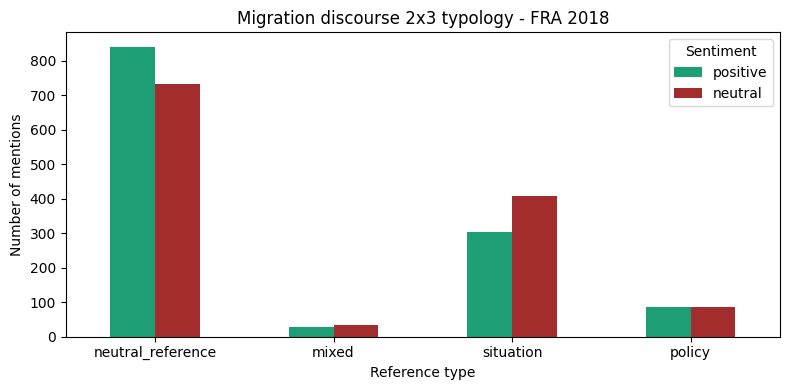

In [11]:
matrix_pd = matrix.to_pandas().set_index("ref_type")

fig, ax = plt.subplots(figsize=(8, 4))
matrix_pd.plot(kind="bar", stacked=False, ax=ax,
               color=["#1d9e75", "#a32d2d", "#888780"])
ax.set_title(f"Migration discourse 2x3 typology - {SOURCE_COUNTRY} {SOURCE_YEAR}")
ax.set_xlabel("Reference type")
ax.set_ylabel("Number of mentions")
ax.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()